# Projeto Machine Learning

#### Membros do grupo : Pedro Garcia e Pedro Machado

#### APS 2 : entrega 03/05

# Classificação - Adult Census Income Dataset

**Dataset:** [Adult Census Income](https://archive.ics.uci.edu/ml/datasets/Adult) da UCI Machine Learning Repository

**Objetivo:** Prever se a renda anual de um indivíduo excede $50K/ano com base em dados do censo.

Este notebook realiza um pipeline completo de classificação para treinar, comparar, otimizar e interpretar modelos de Machine Learning. A APS2 utiliza os achados da APS1 como base, principalmente o desbalanceamento do target e o alto poder discriminativo de variáveis como `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`, `age`, `marital-status`, `occupation` e `relationship`.

Além dos modelos, o notebook inclui feature engineering, validação cruzada robusta, tuning de hiperparâmetros, análise de threshold, matriz de confusão, ROC-AUC, PR-AUC, interpretação das features e discussão crítica.

In [1]:
# imports e config de plots
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

## 1. Carregamento e Inspeção Inicial dos Dados

### 1.1 Carregamento dos dados

In [2]:
# carrega adult.data + adult.test e concatena para inspeção geral
COLUNAS = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income",
]


def ler_adult(path, skiprows=0):
    df_local = pd.read_csv(
        path,
        names=COLUNAS,
        skiprows=skiprows,
        skipinitialspace=True,
        na_values="",
    )

    # padroniza strings e remove o ponto final do target no adult.test
    for col in df_local.select_dtypes(include="object").columns:
        df_local[col] = df_local[col].str.strip()

    df_local["income"] = df_local["income"].str.replace(".", "", regex=False)
    df_local["target"] = (df_local["income"] == ">50K").astype(int)
    return df_local


df_train = ler_adult("adult.data", skiprows=0)
df_test = ler_adult("adult.test", skiprows=1)
df = pd.concat([df_train.assign(split="train"), df_test.assign(split="test")], ignore_index=True)

print(f"Treino oficial: {df_train.shape[0]:,} linhas")
print(f"Teste oficial:  {df_test.shape[0]:,} linhas")
print(f"Total:          {df.shape[0]:,} linhas")
display(df.head())

Treino oficial: 32,561 linhas
Teste oficial:  16,281 linhas
Total:          48,842 linhas


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target,split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,train


### 1.2 Descrição das Features

| Feature | Tipo | Descrição |
|---------|------|-----------|
| **age** | Numérico | Idade do indivíduo em anos |
| **workclass** | Categórico | Classe de trabalho: Private, Self-emp, governo, sem pagamento etc. |
| **fnlwgt** | Numérico | Peso final do censo, representando quantas pessoas aquela linha simboliza |
| **education** | Categórico | Nível de educação declarado |
| **education-num** | Numérico | Educação em escala ordinal numérica |
| **marital-status** | Categórico | Estado civil |
| **occupation** | Categórico | Ocupação profissional |
| **relationship** | Categórico | Relação familiar no domicílio |
| **race** | Categórico | Raça declarada |
| **sex** | Categórico | Sexo declarado |
| **capital-gain** | Numérico | Ganho de capital |
| **capital-loss** | Numérico | Perda de capital |
| **hours-per-week** | Numérico | Horas trabalhadas por semana |
| **native-country** | Categórico | País de origem |
| **income** | Target | Classe de renda: `<=50K` ou `>50K` |

A variável `target` foi criada como versão binária de `income`: `0` para `<=50K` e `1` para `>50K`.

### 1.3 Checagens iniciais

Nesta etapa confirmamos tipos de variáveis, valores ausentes e desequilíbrio do target. O desbalanceamento é central: como a classe `>50K` é minoritária, a avaliação precisa considerar principalmente **F1**, **ROC-AUC** e **PR-AUC**, não apenas acurácia.

Tipos de dados:


,tipo
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object



Valores ausentes no treino:


,missing_treino
occupation,1843
workclass,1836
native-country,583


,treino_abs,treino_pct,teste_abs,teste_pct
income,,,,
<=50K,24720,0.7592,12435,0.7638
>50K,7841,0.2408,3846,0.2362


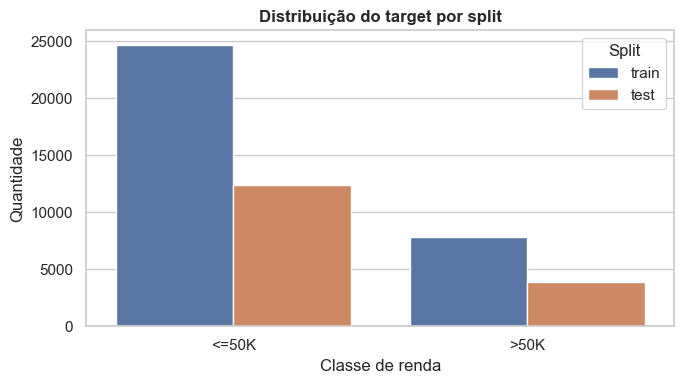

In [3]:
# dimensões, tipos e missing
print("Tipos de dados:")
display(df_train.drop(columns=["target"]).dtypes.to_frame("tipo"))

missing = df_train.drop(columns=["target"]).isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nValores ausentes no treino:")
display(missing.to_frame("missing_treino"))

target_dist = pd.DataFrame({
    "treino_abs": df_train["income"].value_counts(),
    "treino_pct": df_train["income"].value_counts(normalize=True),
    "teste_abs": df_test["income"].value_counts(),
    "teste_pct": df_test["income"].value_counts(normalize=True),
})
display(target_dist)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="income", hue="split", ax=ax)
ax.set_title("Distribuição do target por split")
ax.set_xlabel("Classe de renda")
ax.set_ylabel("Quantidade")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

### 2.1 Criação de novas features

As novas features foram criadas a partir dos achados da APS1 e do enunciado da APS2. O objetivo não é apenas aumentar performance, mas também representar relações plausíveis:

| Nova feature | Tipo | Justificativa |
|---|---|---|
| `capital-net` | numérica | Diferença entre `capital-gain` e `capital-loss`; resume retorno líquido de capital. |
| `has-capital-gain`, `has-capital-loss` | binárias | Capturam a presença de ganho/perda de capital, pois a distribuição é muito concentrada em zero. |
| `work-experience-proxy` | numérica | Proxy simples de experiência: `age - education-num - 6`. |
| `education-hours` | numérica | Interação entre escolaridade e carga horária semanal. |
| `age-hours` e `hours-per-age` | numéricas | Relações entre ciclo de vida e intensidade de trabalho. |
| `age-group`, `work-intensity`, `capital-profile` | categóricas | Binning interpretável para relações não lineares. |
| `marital-age`, `sex-hours`, `education-occupation` | categóricas | Interações sugeridas pela EDA entre demografia, ocupação e renda. |

Foram criadas mais de 3 features, como exigido, usando uma função simples (`def criar_features`) aplicada separadamente no treino e no teste oficial. Como as regras usam bins fixos e operações por linha, não há vazamento de dados.

In [4]:
FEATURES_ORIGINAIS = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
]


def criar_features(X):
    # cria features novas a partir das colunas originais
    X = X.copy()

    age = X["age"].astype(float)
    education_num = X["education-num"].astype(float)
    hours = X["hours-per-week"].astype(float)
    capital_gain = X["capital-gain"].fillna(0).astype(float)
    capital_loss = X["capital-loss"].fillna(0).astype(float)

    X["capital-net"] = capital_gain - capital_loss
    X["has-capital-gain"] = (capital_gain > 0).astype(int)
    X["has-capital-loss"] = (capital_loss > 0).astype(int)
    X["work-experience-proxy"] = (age - education_num - 6).clip(lower=0)
    X["education-hours"] = education_num * hours
    X["age-hours"] = age * hours
    X["hours-per-age"] = hours / age.replace(0, np.nan)

    X["age-group"] = pd.cut(
        age,
        bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
        include_lowest=True,
    ).astype("object")

    X["work-intensity"] = pd.cut(
        hours,
        bins=[0, 34, 40, 50, 100],
        labels=["part-time", "standard", "extended", "heavy"],
        include_lowest=True,
    ).astype("object")

    X["capital-profile"] = np.select(
        [
            (capital_gain > 0) & (capital_loss > 0),
            capital_gain > 0,
            capital_loss > 0,
        ],
        ["gain_and_loss", "gain_only", "loss_only"],
        default="neutral",
    )

    X["marital-age"] = (
        X["marital-status"].fillna("Unknown").astype(str)
        + "_"
        + X["age-group"].fillna("Unknown").astype(str)
    )
    X["sex-hours"] = (
        X["sex"].fillna("Unknown").astype(str)
        + "_"
        + X["work-intensity"].fillna("Unknown").astype(str)
    )
    X["education-occupation"] = (
        X["education"].fillna("Unknown").astype(str)
        + "_"
        + X["occupation"].fillna("Unknown").astype(str)
    )

    return X


NOVAS_FEATURES = [
    "capital-net", "has-capital-gain", "has-capital-loss",
    "work-experience-proxy", "education-hours", "age-hours", "hours-per-age",
    "age-group", "work-intensity", "capital-profile",
    "marital-age", "sex-hours", "education-occupation",
]

amostra_fe = criar_features(df_train[FEATURES_ORIGINAIS].head(10))
print("Amostra das novas features:")
display(amostra_fe[NOVAS_FEATURES].head())

Amostra das novas features:


,capital-net,has-capital-gain,has-capital-loss,work-experience-proxy,education-hours,age-hours,hours-per-age,age-group,work-intensity,capital-profile,marital-age,sex-hours,education-occupation
0,"2,174.0000",1,0,20.0000,520.0000,"1,560.0000",1.0256,36-45,standard,gain_only,Never-married_36-45,Male_standard,Bachelors_Adm-clerical
1,0.0000,0,0,31.0000,169.0000,650.0000,0.2600,46-55,part-time,neutral,Married-civ-spouse_46-55,Male_part-time,Bachelors_Exec-managerial
2,0.0000,0,0,23.0000,360.0000,"1,520.0000",1.0526,36-45,standard,neutral,Divorced_36-45,Male_standard,HS-grad_Handlers-cleaners
3,0.0000,0,0,40.0000,280.0000,"2,120.0000",0.7547,46-55,standard,neutral,Married-civ-spouse_46-55,Male_standard,11th_Handlers-cleaners
4,0.0000,0,0,9.0000,520.0000,"1,120.0000",1.4286,26-35,standard,neutral,Married-civ-spouse_26-35,Female_standard,Bachelors_Prof-specialty


## 3. Pré-processamento e Estratégia de Balanceamento

### Decisões de pré-processamento

- **Numéricas:** imputação pela mediana e padronização com `StandardScaler`.
- **Categóricas:** imputação pela moda e codificação `OneHotEncoder(handle_unknown='ignore')`.
- **Separação treino/teste:** uso do split oficial da UCI (`adult.data` para treino e `adult.test` para teste final).
- **Vazamento de dados:** as novas features são criadas por função determinística; depois, imputação, escala e one-hot ficam dentro de `Pipeline`.

### 3.2 Balanceamento

O dataset é desbalanceado, com predominância da classe `<=50K`. Para evitar um modelo que apenas favoreça a classe majoritária:

1. Utilizamos `class_weight='balanced'` nos modelos lineares;
2. Utilizamos `class_weight='balanced_subsample'` no Random Forest;
3. Ajustamos o **threshold de decisão** usando predições out-of-fold, maximizando F1 da classe positiva.

Não foi usado SMOTE como estratégia principal porque o dataset tem muitas variáveis categóricas one-hot; sintetizar pontos artificiais nesse espaço pode criar perfis pouco realistas. Class weights e threshold moving são mais simples, reprodutíveis e adequados ao pipeline do Scikit-learn.

In [5]:
X_train = criar_features(df_train[FEATURES_ORIGINAIS])
y_train = df_train["target"].copy()
X_test = criar_features(df_test[FEATURES_ORIGINAIS])
y_test = df_test["target"].copy()

NUMERICAS_ORIGINAIS = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CATEGORICAS_ORIGINAIS = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]

NUMERICAS_NOVAS = [
    "capital-net", "has-capital-gain", "has-capital-loss",
    "work-experience-proxy", "education-hours", "age-hours", "hours-per-age",
]
CATEGORICAS_NOVAS = [
    "age-group", "work-intensity", "capital-profile",
    "marital-age", "sex-hours", "education-occupation",
]

NUMERICAS = NUMERICAS_ORIGINAIS + NUMERICAS_NOVAS
CATEGORICAS = CATEGORICAS_ORIGINAIS + CATEGORICAS_NOVAS


def criar_ohe():
    # compatível com sklearn novo (sparse_output) e antigo (sparse)
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def criar_preprocessador():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", criar_ohe()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERICAS),
            ("cat", categorical_pipeline, CATEGORICAS),
        ],
        remainder="drop",
    )


def montar_pipeline(modelo):
    return Pipeline(steps=[
        ("preprocess", criar_preprocessador()),
        ("model", modelo),
    ])


print("Shape do treino com novas features:", X_train.shape)
print("Shape do teste com novas features:", X_test.shape)
print("Distribuição do target no treino:")
display(y_train.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}).to_frame("proporcao"))
print("Distribuição do target no teste:")
display(y_test.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}).to_frame("proporcao"))

Shape do treino com novas features: (32561, 27)
Shape do teste com novas features: (16281, 27)
Distribuição do target no treino:


,proporcao
target,
<=50K,0.7592
>50K,0.2408


Distribuição do target no teste:


,proporcao
target,
<=50K,0.7638
>50K,0.2362


## 4. Modelagem

### 4.1 Modelos avaliados

Foram avaliados 4 modelos para cobrir os requisitos e ter comparação real:

1. **DummyClassifier:** baseline ingênuo;
2. **RidgeClassifier:** baseline linear regularizado, equivalente apropriado para classificação;
3. **Logistic Regression:** modelo linear probabilístico com `class_weight='balanced'`;
4. **Random Forest:** ensemble não linear com `class_weight='balanced_subsample'`.

Como a tarefa é de classificação binária, usamos modelos lineares classificadores em vez de regressão linear comum. Isso preserva a intenção do enunciado sem produzir saídas incompatíveis com probabilidades de classe.

In [6]:
modelos = {
    "Dummy": montar_pipeline(DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
    "Ridge Classifier": montar_pipeline(RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    "Logistic Regression": montar_pipeline(
        LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": montar_pipeline(
        RandomForestClassifier(
            n_estimators=80,
            max_depth=None,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
}

cv_robusta = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

resultados_cv = []
fold_scores_pr_auc = {}

for nome, pipeline in modelos.items():
    print(f"Rodando validação cruzada: {nome}")
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_robusta,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    fold_scores_pr_auc[nome] = scores["test_pr_auc"]

    linha = {"modelo": nome}
    for metrica in scoring:
        vals = scores[f"test_{metrica}"]
        linha[f"{metrica}_mean"] = vals.mean()
        linha[f"{metrica}_std"] = vals.std()
    resultados_cv.append(linha)

cv_summary = pd.DataFrame(resultados_cv).set_index("modelo").sort_values("pr_auc_mean", ascending=False)
display(cv_summary)

Rodando validação cruzada: Dummy


Rodando validação cruzada: Ridge Classifier


Rodando validação cruzada: Logistic Regression


Rodando validação cruzada: Random Forest


,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
modelo,,,,,,,,,,,,,,
Random Forest,0.8391,0.0038,0.7806,0.0044,0.8242,0.0049,0.7969,0.0046,0.8449,0.0036,0.9143,0.0031,0.7922,0.0076
Logistic Regression,0.8177,0.0029,0.7647,0.0031,0.8313,0.0042,0.7820,0.0034,0.8277,0.0027,0.9145,0.0029,0.7875,0.0091
Ridge Classifier,0.8002,0.0047,0.7500,0.0044,0.8192,0.0052,0.7648,0.0050,0.8121,0.0043,0.9009,0.0042,0.7463,0.0126
Dummy,0.7592,0.0000,0.3796,0.0000,0.5000,0.0000,0.4316,0.0000,0.6553,0.0001,0.5000,0.0000,0.2408,0.0000


### 4.2 Comparação estatística entre modelos

Como todos os modelos foram avaliados nos mesmos folds, a comparação de PR-AUC pode ser pareada. Usamos um teste pareado de permutação por troca de sinais, implementado apenas com `NumPy`, entre o melhor modelo médio e os demais. O objetivo é verificar se a vantagem observada é apenas ruído da validação cruzada ou uma diferença consistente.

In [7]:
melhor_nome_cv = cv_summary.index[0]
comparacoes = []

def p_valor_troca_de_sinais(diff):
    # Teste pareado de permutação: sob H0, o sinal das diferenças por fold é aleatório.
    diff = np.asarray(diff, dtype=float)
    if np.allclose(diff, 0):
        return 1.0

    observado = abs(diff.mean())
    n = len(diff)

    if n <= 20:
        sinais = np.array([
            [1 if (mask >> bit) & 1 else -1 for bit in range(n)]
            for mask in range(2 ** n)
        ])
    else:
        rng = np.random.default_rng(RANDOM_STATE)
        sinais = rng.choice([-1, 1], size=(20000, n))

    medias_nulas = np.abs((sinais * diff).mean(axis=1))
    return (np.sum(medias_nulas >= observado) + 1) / (len(medias_nulas) + 1)


for nome, scores_modelo in fold_scores_pr_auc.items():
    if nome == melhor_nome_cv:
        continue

    diff = fold_scores_pr_auc[melhor_nome_cv] - scores_modelo

    p_valor = p_valor_troca_de_sinais(diff)

    comparacoes.append({
        "melhor_modelo": melhor_nome_cv,
        "comparado_com": nome,
        "delta_pr_auc_medio": diff.mean(),
        "p_valor_troca_de_sinais": p_valor,
        "diferenca_significativa_5pct": bool(p_valor < 0.05),
    })

comparacoes_df = pd.DataFrame(comparacoes).sort_values("delta_pr_auc_medio", ascending=False)
display(comparacoes_df)

,melhor_modelo,comparado_com,delta_pr_auc_medio,p_valor_troca_de_sinais,diferenca_significativa_5pct
0,Random Forest,Dummy,0.5514,0.0029,True
1,Random Forest,Ridge Classifier,0.0459,0.0029,True
2,Random Forest,Logistic Regression,0.0047,0.0107,True


## 5. Otimização de Hiperparâmetros

A validação cruzada inicial identifica os candidatos mais fortes. Em seguida, otimizamos dois modelos representativos:

- **Logistic Regression:** controla regularização (`C`) e tipo de penalidade (`l1`/`l2`);
- **Random Forest:** controla número de árvores, profundidade, tamanho mínimo das folhas, número de features por split e amostragem.

A métrica de otimização é **PR-AUC**, pois o problema é desbalanceado e queremos bom desempenho na classe `>50K`.

In [8]:
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

buscas = {
    "Logistic Regression Tuned": {
        "estimator": montar_pipeline(
            LogisticRegression(
                max_iter=1500,
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
        "params": {
            "model__C": np.logspace(-2, 1, 10),
            "model__penalty": ["l1", "l2"],
        },
        "n_iter": 12,
    },
    "Random Forest Tuned": {
        "estimator": montar_pipeline(
            RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
        "params": {
            "model__n_estimators": [80, 120, 160],
            "model__max_depth": [None, 10, 16, 22],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": ["sqrt", "log2"],
            "model__max_samples": [0.70, 0.85, None],
        },
        "n_iter": 8,
    },
}

best_estimators = {}
tuning_resultados = []

for nome, cfg in buscas.items():
    print(f"Otimizando: {nome}")
    search = RandomizedSearchCV(
        estimator=cfg["estimator"],
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="average_precision",
        cv=cv_tuning,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best_estimators[nome] = search.best_estimator_

    tuning_resultados.append({
        "modelo": nome,
        "pr_auc_cv_tuning": search.best_score_,
        "melhores_parametros": search.best_params_,
    })

tuning_df = pd.DataFrame(tuning_resultados).set_index("modelo").sort_values("pr_auc_cv_tuning", ascending=False)
display(tuning_df)

Otimizando: Logistic Regression Tuned


Otimizando: Random Forest Tuned


,pr_auc_cv_tuning,melhores_parametros
modelo,,
Random Forest Tuned,0.7941,"{'model__n_estimators': 80, 'model__min_sample..."
Logistic Regression Tuned,0.7888,"{'model__penalty': 'l1', 'model__C': 0.2154434..."


## 6. Threshold Moving

O threshold padrão `0.50` nem sempre é ótimo em dados desbalanceados. Para evitar usar o teste como validação, calculamos probabilidades **out-of-fold** no treino e escolhemos o threshold que maximiza F1 para a classe positiva (`>50K`).

Modelo escolhido pelo tuning (PR-AUC): Random Forest Tuned


Melhor threshold por F1 out-of-fold: 0.5900


,threshold,precision,recall,f1
21871,0.5900,0.6581,0.7637,0.7070


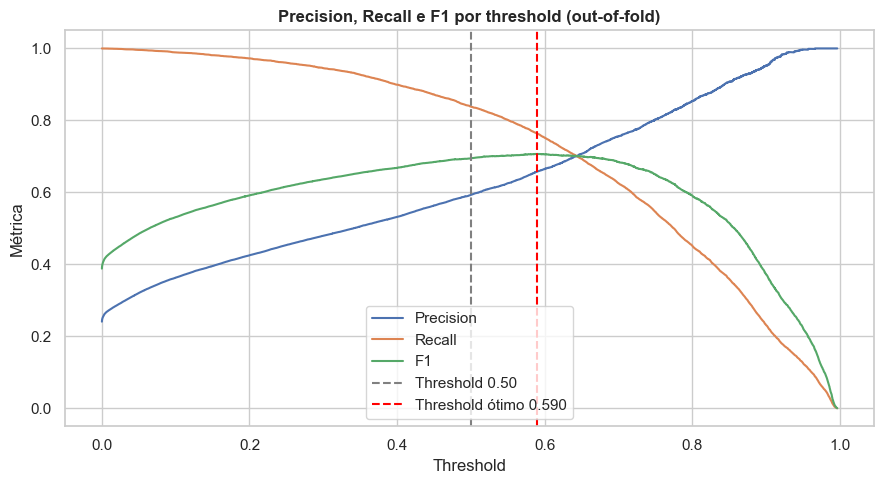

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital-net',
                                                   'has-capital-gain',
                                                   'has-capital-loss',
                                                   'work-experience-proxy',
                                                   'education-hours',
                                                   'age-hours',
                                                   'hour...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age-group',
                                                   'work-intensity',
                                                   'capital-profile',
                                                   'marital-age', 'sex-hours',
                                                   'education-occupation'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_samples=0.85, min_samples_leaf=5,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [9]:
final_nome = tuning_df.index[0]
final_modelo = best_estimators[final_nome]

print(f"Modelo escolhido pelo tuning (PR-AUC): {final_nome}")

probas_oof = cross_val_predict(
    final_modelo,
    X_train,
    y_train,
    cv=cv_tuning,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, probas_oof)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_scores[:-1],
})

idx_best_thr = threshold_table["f1"].idxmax()
threshold_otimo = float(threshold_table.loc[idx_best_thr, "threshold"])

print(f"Melhor threshold por F1 out-of-fold: {threshold_otimo:.4f}")
display(threshold_table.loc[[idx_best_thr]])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
ax.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
ax.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
ax.axvline(0.50, color="gray", linestyle="--", label="Threshold 0.50")
ax.axvline(threshold_otimo, color="red", linestyle="--", label=f"Threshold ótimo {threshold_otimo:.3f}")
ax.set_title("Precision, Recall e F1 por threshold (out-of-fold)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.legend()
plt.tight_layout()
plt.show()

final_modelo.fit(X_train, y_train)

## 7. Avaliação no Teste Oficial

As métricas abaixo são calculadas no `adult.test`, que não participou do treinamento, validação cruzada, tuning ou escolha do threshold.

Métricas obrigatórias reportadas:

- Accuracy;
- Precision, Recall e F1-score macro, weighted e por classe;
- ROC-AUC;
- PR-AUC;
- Confusion Matrix com análise de falsos positivos e falsos negativos.

In [10]:
def scores_positivos(estimator, X):
    # Retorna score da classe positiva, usando probabilidade quando disponível.
    model_step = estimator.named_steps["model"] if isinstance(estimator, Pipeline) else estimator
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(model_step, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def avaliar_modelo(estimator, X, y, threshold=0.50, nome="modelo"):
    scores = scores_positivos(estimator, X)
    y_pred = (scores >= threshold).astype(int)

    report = classification_report(
        y,
        y_pred,
        target_names=["<=50K", ">50K"],
        output_dict=True,
        zero_division=0,
    )

    return {
        "modelo": nome,
        "threshold": threshold,
        "accuracy": accuracy_score(y, y_pred),
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted": report["weighted avg"]["recall"],
        "f1_weighted": report["weighted avg"]["f1-score"],
        "precision_<=50K": report["<=50K"]["precision"],
        "recall_<=50K": report["<=50K"]["recall"],
        "f1_<=50K": report["<=50K"]["f1-score"],
        "precision_>50K": report[">50K"]["precision"],
        "recall_>50K": report[">50K"]["recall"],
        "f1_>50K": report[">50K"]["f1-score"],
        "roc_auc": roc_auc_score(y, scores),
        "pr_auc": average_precision_score(y, scores),
    }


avaliacoes = []

for nome, est in best_estimators.items():
    est.fit(X_train, y_train)
    avaliacoes.append(avaliar_modelo(est, X_test, y_test, threshold=0.50, nome=f"{nome} | thr=0.50"))

avaliacoes.append(
    avaliar_modelo(
        final_modelo,
        X_test,
        y_test,
        threshold=threshold_otimo,
        nome=f"{final_nome} | thr_otimo",
    )
)

avaliacao_df = pd.DataFrame(avaliacoes).sort_values(["pr_auc", "f1_>50K"], ascending=False)
display(avaliacao_df)

,modelo,threshold,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_<=50K,recall_<=50K,f1_<=50K,precision_>50K,recall_>50K,f1_>50K,roc_auc,pr_auc
2,Random Forest Tuned | thr_otimo,0.5900,0.8444,0.7830,0.8137,0.7959,0.8554,0.8444,0.8484,0.9202,0.8718,0.8954,0.6458,0.7556,0.6964,0.9129,0.7882
1,Random Forest Tuned | thr=0.50,0.5000,0.8202,0.7627,0.8267,0.7808,0.8575,0.8202,0.8298,0.9424,0.8143,0.8737,0.5829,0.8391,0.6879,0.9129,0.7882
0,Logistic Regression Tuned | thr=0.50,0.5000,0.8156,0.7601,0.8285,0.7777,0.8584,0.8156,0.8261,0.9465,0.8039,0.8694,0.5737,0.8531,0.6860,0.9127,0.7829


Modelo final: Random Forest Tuned
Threshold final: 0.5900

Classification report:
              precision    recall  f1-score   support

       <=50K     0.9202    0.8718    0.8954     12435
        >50K     0.6458    0.7556    0.6964      3846

    accuracy                         0.8444     16281
   macro avg     0.7830    0.8137    0.7959     16281
weighted avg     0.8554    0.8444    0.8484     16281

Análise da matriz de confusão:
TN (real <=50K e previsto <=50K): 10,841
FP (real <=50K e previsto >50K):  1,594
FN (real >50K e previsto <=50K):  940
TP (real >50K e previsto >50K):   2,906

Falsos positivos significam classificar uma pessoa de renda <=50K como >50K.
Falsos negativos significam deixar de identificar uma pessoa de renda >50K.
O threshold ótimo busca equilibrar esse trade-off, melhorando o F1 da classe minoritária.


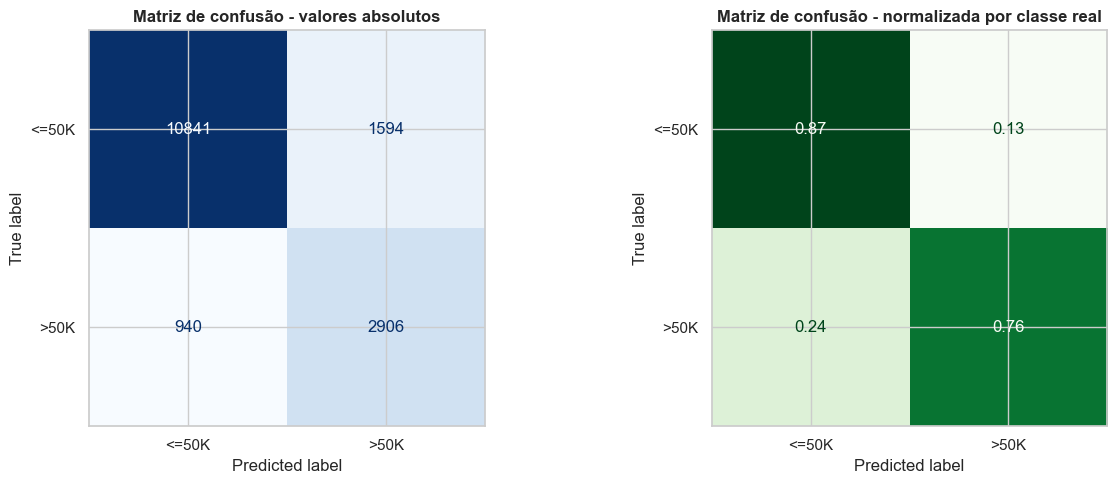

In [11]:
# relatório detalhado e matriz de confusão do modelo final
scores_final = scores_positivos(final_modelo, X_test)
y_pred_final = (scores_final >= threshold_otimo).astype(int)

print(f"Modelo final: {final_nome}")
print(f"Threshold final: {threshold_otimo:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_final, target_names=["<=50K", ">50K"], digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print("Análise da matriz de confusão:")
print(f"TN (real <=50K e previsto <=50K): {tn:,}")
print(f"FP (real <=50K e previsto >50K):  {fp:,}")
print(f"FN (real >50K e previsto <=50K):  {fn:,}")
print(f"TP (real >50K e previsto >50K):   {tp:,}")
print()
print("Falsos positivos significam classificar uma pessoa de renda <=50K como >50K.")
print("Falsos negativos significam deixar de identificar uma pessoa de renda >50K.")
print("O threshold ótimo busca equilibrar esse trade-off, melhorando o F1 da classe minoritária.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Matriz de confusão - valores absolutos")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["<=50K", ">50K"],
    cmap="Greens",
    normalize="true",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Matriz de confusão - normalizada por classe real")

plt.tight_layout()
plt.show()

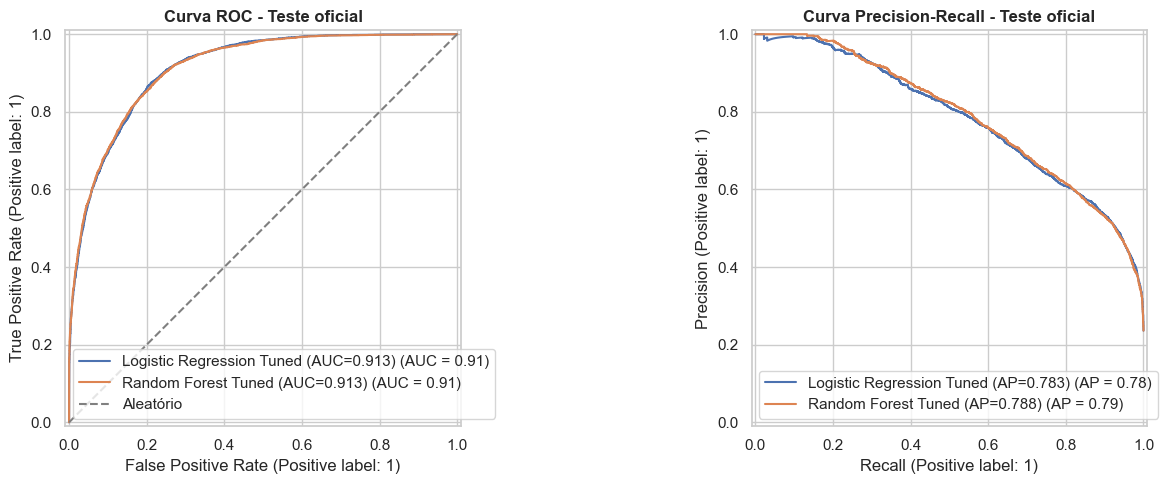

In [12]:
# curvas ROC e Precision-Recall no teste oficial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nome, est in best_estimators.items():
    scores = scores_positivos(est, X_test)
    RocCurveDisplay.from_predictions(
        y_test,
        scores,
        name=f"{nome} (AUC={roc_auc_score(y_test, scores):.3f})",
        ax=axes[0],
    )
    PrecisionRecallDisplay.from_predictions(
        y_test,
        scores,
        name=f"{nome} (AP={average_precision_score(y_test, scores):.3f})",
        ax=axes[1],
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
axes[0].set_title("Curva ROC - Teste oficial")
axes[1].set_title("Curva Precision-Recall - Teste oficial")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Interpretação e Explicabilidade

A interpretação combina duas leituras:

1. **Importância interna do modelo final**: coeficientes absolutos para modelos lineares ou `feature_importances_` para Random Forest;
2. **Permutation importance**: mede a queda de PR-AUC quando uma variável original é embaralhada, funcionando como análise model-agnostic.

Isso ajuda a responder explicitamente quais variáveis melhor separam as classes.

Tipo de importância usado no modelo final: feature_importances


,feature_pos_preprocess,importancia,tipo
39,cat__marital-status_Married-civ-spouse,0.0845,feature_importances
10,num__education-hours,0.0787,feature_importances
11,num__age-hours,0.0545,feature_importances
0,num__age,0.0523,feature_importances
2,num__education-num,0.0520,feature_importances
58,cat__relationship_Husband,0.0475,feature_importances
41,cat__marital-status_Never-married,0.0449,feature_importances
6,num__capital-net,0.0375,feature_importances
3,num__capital-gain,0.0333,feature_importances
9,num__work-experience-proxy,0.0249,feature_importances


,variavel,importancia
17,marital-status,0.1440
21,relationship,0.1101
16,marital-age,0.0793
8,education-hours,0.0787
2,age-hours,0.0545
0,age,0.0523
9,education-num,0.0520
19,occupation,0.0412
5,capital-net,0.0375
1,age-group,0.0356


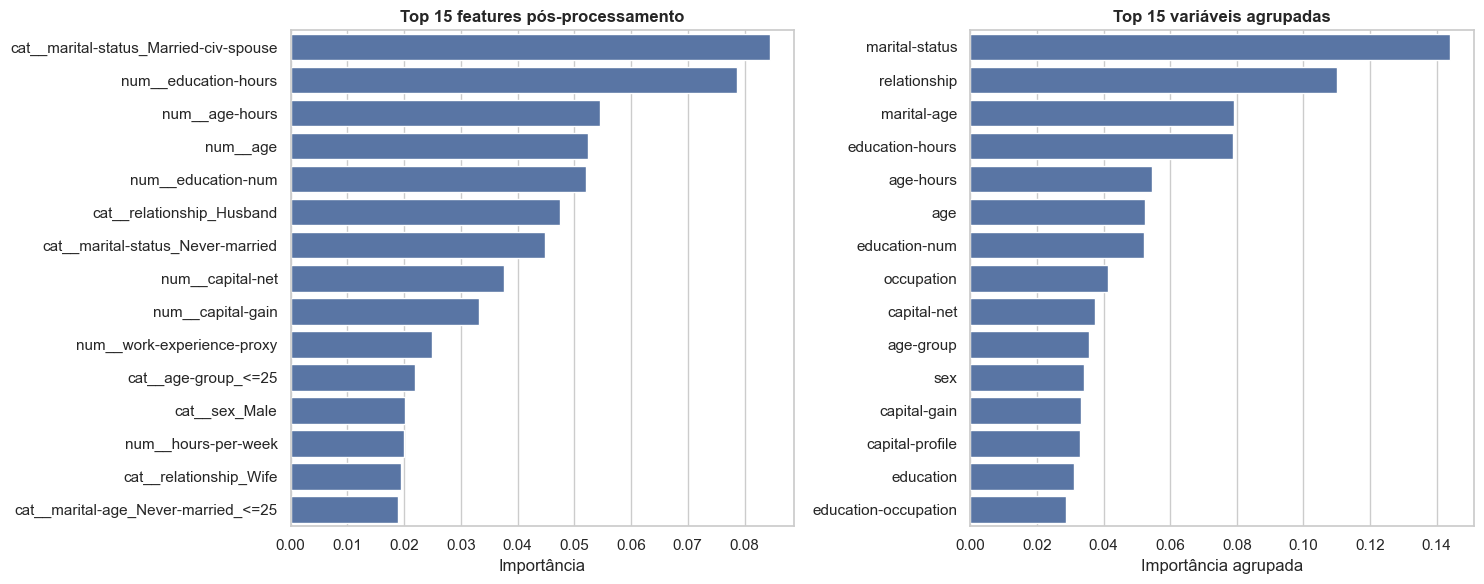

In [13]:
def nomes_features_pos_preprocess(estimator):
    return estimator.named_steps["preprocess"].get_feature_names_out()


def recuperar_importancias(estimator):
    feature_names = nomes_features_pos_preprocess(estimator)
    model_step = estimator.named_steps["model"]

    if hasattr(model_step, "feature_importances_"):
        importancias = model_step.feature_importances_
        tipo = "feature_importances"
    elif hasattr(model_step, "coef_"):
        importancias = np.abs(model_step.coef_).ravel()
        tipo = "abs_coeficientes"
    else:
        raise ValueError("Modelo sem coeficientes ou feature_importances_.")

    return pd.DataFrame({
        "feature_pos_preprocess": feature_names,
        "importancia": importancias,
        "tipo": tipo,
    }).sort_values("importancia", ascending=False)


def agrupar_importancias(df_importancias):
    colunas_categoricas_ordenadas = sorted(CATEGORICAS, key=len, reverse=True)

    def origem(nome):
        limpo = nome.split("__", 1)[1] if "__" in nome else nome
        if limpo in NUMERICAS:
            return limpo
        for col in colunas_categoricas_ordenadas:
            if limpo.startswith(col + "_"):
                return col
        return limpo

    out = df_importancias.copy()
    out["variavel"] = out["feature_pos_preprocess"].map(origem)
    return (
        out.groupby("variavel", as_index=False)["importancia"]
        .sum()
        .sort_values("importancia", ascending=False)
    )


importancias_final = recuperar_importancias(final_modelo)
importancias_grupo = agrupar_importancias(importancias_final)

print(f"Tipo de importância usado no modelo final: {importancias_final['tipo'].iloc[0]}")
display(importancias_final.head(20))
display(importancias_grupo.head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=importancias_final.head(15),
    y="feature_pos_preprocess",
    x="importancia",
    ax=axes[0],
)
axes[0].set_title("Top 15 features pós-processamento")
axes[0].set_xlabel("Importância")
axes[0].set_ylabel("")

sns.barplot(
    data=importancias_grupo.head(15),
    y="variavel",
    x="importancia",
    ax=axes[1],
)
axes[1].set_title("Top 15 variáveis agrupadas")
axes[1].set_xlabel("Importância agrupada")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

,variavel_original,queda_media_pr_auc,queda_std
14,capital-net,0.0623,0.0018
5,marital-status,0.0518,0.0122
10,capital-gain,0.0441,0.0016
7,relationship,0.0266,0.0093
23,capital-profile,0.0245,0.0028
4,education-num,0.0138,0.0036
18,education-hours,0.0138,0.0032
15,has-capital-gain,0.0116,0.0009
0,age,0.0097,0.0034
11,capital-loss,0.0096,0.0006


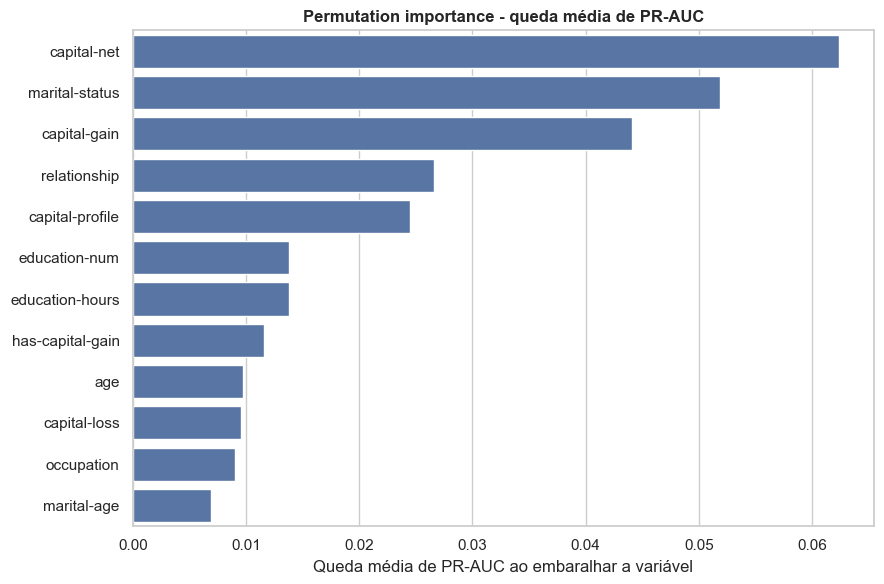

In [14]:
# permutation importance em amostra do teste, usando PR-AUC
n_perm = min(2500, len(X_test))
X_perm = X_test.sample(n=n_perm, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    final_modelo,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

perm_df = pd.DataFrame({
    "variavel_original": X_perm.columns,
    "queda_media_pr_auc": perm.importances_mean,
    "queda_std": perm.importances_std,
}).sort_values("queda_media_pr_auc", ascending=False)

display(perm_df)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=perm_df.head(12), y="variavel_original", x="queda_media_pr_auc", ax=ax)
ax.set_title("Permutation importance - queda média de PR-AUC")
ax.set_xlabel("Queda média de PR-AUC ao embaralhar a variável")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 9. Análise de Subgrupos e Vieses

Como o dataset contém variáveis sensíveis (`sex`, `race`) e representa dados censitários de 1994, é importante olhar o comportamento do modelo por subgrupos. Esta análise não transforma o notebook em auditoria de fairness completa, mas evita tratar performance média como se fosse igual para todos.

In [15]:
def metricas_por_grupo(coluna):
    temp = X_test[[coluna]].copy()
    temp["y_true"] = y_test.values
    temp["y_pred"] = y_pred_final

    linhas = []
    for grupo, parte in temp.groupby(coluna, dropna=False):
        y_g = parte["y_true"].values
        pred_g = parte["y_pred"].values
        if len(np.unique(y_g)) < 2:
            recall_pos = np.nan
            fpr = np.nan
        else:
            tn_g, fp_g, fn_g, tp_g = confusion_matrix(y_g, pred_g, labels=[0, 1]).ravel()
            recall_pos = tp_g / (tp_g + fn_g) if (tp_g + fn_g) > 0 else np.nan
            fpr = fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else np.nan

        linhas.append({
            coluna: grupo,
            "n": len(parte),
            "taxa_real_>50K": y_g.mean(),
            "taxa_prevista_>50K": pred_g.mean(),
            "recall_>50K": recall_pos,
            "false_positive_rate": fpr,
        })
    return pd.DataFrame(linhas).sort_values("n", ascending=False)


audit_sex = metricas_por_grupo("sex")
audit_race = metricas_por_grupo("race")

display(audit_sex)
display(audit_race)

,sex,n,taxa_real_>50K,taxa_prevista_>50K,recall_>50K,false_positive_rate
1,Male,10860,0.2998,0.3657,0.7804,0.1882
0,Female,5421,0.1088,0.0974,0.6186,0.0337


,race,n,taxa_real_>50K,taxa_prevista_>50K,recall_>50K,false_positive_rate
4,White,13946,0.2503,0.2937,0.7593,0.1383
2,Black,1561,0.1147,0.1326,0.7095,0.0579
1,Asian-Pac-Islander,480,0.2771,0.3146,0.7444,0.1499
0,Amer-Indian-Eskimo,159,0.1195,0.1635,0.7895,0.0786
3,Other,135,0.1852,0.1481,0.6000,0.0455


## 10. Documentação e Apresentação

### 10.1 Resumo Executivo dos Resultados

A célula abaixo consolida automaticamente as principais métricas obtidas. Ela é útil para o relatório final porque evita copiar valores manualmente e garante coerência entre resultados e conclusão.

In [16]:
linha_final = avaliacao_df[avaliacao_df["modelo"] == f"{final_nome} | thr_otimo"].iloc[0]
top_variaveis = importancias_grupo.head(8)["variavel"].tolist()
top_perm = perm_df.head(6)["variavel_original"].tolist()

print("Resumo executivo")
print("=" * 80)
print(f"Modelo final: {final_nome}")
print(f"Threshold escolhido: {threshold_otimo:.4f}")
print(f"Accuracy:  {linha_final['accuracy']:.4f}")
print(f"F1 macro:  {linha_final['f1_macro']:.4f}")
print(f"F1 >50K:   {linha_final['f1_>50K']:.4f}")
print(f"Recall >50K: {linha_final['recall_>50K']:.4f}")
print(f"Precision >50K: {linha_final['precision_>50K']:.4f}")
print(f"ROC-AUC:   {linha_final['roc_auc']:.4f}")
print(f"PR-AUC:    {linha_final['pr_auc']:.4f}")
print()
print("Variáveis mais importantes pelo modelo final:")
print(", ".join(top_variaveis))
print()
print("Variáveis originais mais relevantes por permutation importance:")
print(", ".join(top_perm))

Resumo executivo
Modelo final: Random Forest Tuned
Threshold escolhido: 0.5900
Accuracy:  0.8444
F1 macro:  0.7959
F1 >50K:   0.6964
Recall >50K: 0.7556
Precision >50K: 0.6458
ROC-AUC:   0.9129
PR-AUC:    0.7882

Variáveis mais importantes pelo modelo final:
marital-status, relationship, marital-age, education-hours, age-hours, age, education-num, occupation

Variáveis originais mais relevantes por permutation importance:
capital-net, marital-status, capital-gain, relationship, capital-profile, education-num


## 11. Discussão Crítica e Conclusões

### Principais conclusões

- O **DummyClassifier** confirma que acurácia isolada é enganosa: prever sempre a classe majoritária pode parecer razoável, mas falha na identificação da classe `>50K`.
- Os modelos com **balanceamento por class weight** melhoram a atenção à classe minoritária.
- A métrica **PR-AUC** é a mais informativa para comparar modelos porque a classe positiva é menos frequente.
- O **threshold moving** permite ajustar o trade-off entre precision e recall sem retreinar o modelo.
- As variáveis que melhor separam as classes tendem a envolver escolaridade, estado civil/relacionamento, ocupação, horas trabalhadas, idade e capital. As novas features `capital-net`, `education-hours`, `work-experience-proxy` e interações categóricas ajudam a tornar essas relações mais explícitas.

### Limitações

- **Causalidade vs. correlação:** o modelo identifica padrões estatísticos, mas não prova que uma variável causa maior renda.
- **Viés histórico:** os dados são de 1994 e refletem desigualdades sociais daquele contexto. Usar `sex` e `race` pode aumentar performance, mas exige cuidado ético.
- **Target simplificado:** renda anual foi binarizada em `<=50K` e `>50K`; isso perde nuances e pode esconder subgrupos com padrões diferentes.
- **Multimodalidade e heterogeneidade:** mesmo com target binário, os perfis dentro de cada classe não são homogêneos. Erros podem variar por ocupação, gênero, raça, idade e escolaridade.
- **Heterocedasticidade como analogia de erro:** em classificação, não analisamos variância residual como em regressão, mas a incerteza do modelo pode mudar entre subpopulações.
- **Falsos positivos e falsos negativos têm custos diferentes:** a escolha do threshold deve depender do uso prático do modelo.

### Próximos passos

- Testar calibração de probabilidades (`CalibratedClassifierCV`);
- Fazer auditoria de fairness mais completa por subgrupos;
- Avaliar remoção ou uso controlado de variáveis sensíveis;
- Experimentar SMOTE-NC com cuidado, preservando variáveis categóricas;
- Validar o modelo em dados mais recentes, pois o censo de 1994 pode não representar o cenário atual.

## 12. Referências

- Dua, D. and Graff, C. (2019). **UCI Machine Learning Repository - Adult Data Set**. University of California, Irvine. https://archive.ics.uci.edu/ml/datasets/Adult
- Kohavi, R. (1996). **Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid**. Proceedings of KDD.
- Scikit-learn documentation: https://scikit-learn.org/stable/
- Repositório usado como referência de estilo para a APS1: https://github.com/garciapp2/projeto_machine_learning